# Master Bias Creation

This notebook creates a master bias from 10 raw zero exposures obtained with the Tek2K_3 CCD detector.

The detector uses two amplifiers. Each amplifier is corrected with its own overscan region before the useful detector sections are trimmed and reconstructed into a 2048 × 2048 image.

Workflow:

1. Read the 10 zero frames.
2. Apply row-by-row overscan correction to each amplifier.
3. Trim the overscan regions.
4. Reconstruct the 2048 × 2048 detector image.
5. Median-combine the corrected frames.
6. Inspect robust statistics and amplifier consistency.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats, mad_std

In [2]:
PROJECT_DIR = Path("..").resolve()

BIAS_DIR = PROJECT_DIR / "Bias"
PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

PRODUCTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

bias_files = sorted(BIAS_DIR.glob("*.fits*"))
print(f"Bias frames found: {len(bias_files)}")

Bias frames found: 10


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""
    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i
    raise ValueError(f"No 2D image found in {filename}")


def overscan_correct_and_trim(data):
    """Correct the two amplifiers row-by-row and return a 2048x2048 image."""

    # Amplifier 1
    amp1 = data[:, 10:1034].astype(float)          # TSEC11 = [11:1034,1:2048]
    overscan1 = data[:, 1044:1084].astype(float) # BSEC11 = [1045:1084,1:2048]
    level1 = np.median(overscan1, axis=1, keepdims=True)
    amp1_corrected = amp1 - level1

    # Amplifier 2
    amp2 = data[:, 1134:2158].astype(float)       # TSEC12 = [1135:2158,1:2048]
    overscan2 = data[:, 1084:1124].astype(float) # BSEC12 = [1085:1124,1:2048]
    level2 = np.median(overscan2, axis=1, keepdims=True)
    amp2_corrected = amp2 - level2

    return np.hstack([amp1_corrected, amp2_corrected])

## Inspect one raw bias and its overscan

Raw shape: (2048, 2168)
BSEC11: [1045:1084,1:2048]
BSEC12: [1085:1124,1:2048]
TSEC11: [11:1034,1:2048]
TSEC12: [1135:2158,1:2048]


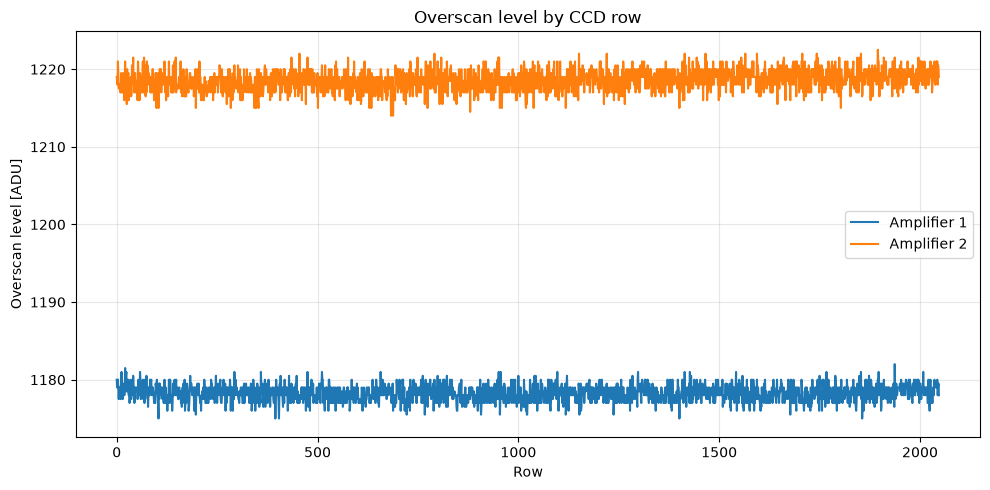

In [4]:
test_file = bias_files[0]
hdu_index = get_image_hdu(test_file)

with fits.open(test_file) as hdul:
    raw_bias = hdul[hdu_index].data.astype(float)
    header = hdul[hdu_index].header

print("Raw shape:", raw_bias.shape)
print("BSEC11:", header["BSEC11"])
print("BSEC12:", header["BSEC12"])
print("TSEC11:", header["TSEC11"])
print("TSEC12:", header["TSEC12"])

overscan1 = raw_bias[:, 1044:1084]
overscan2 = raw_bias[:, 1084:1124]

plt.figure(figsize=(10, 5))
plt.plot(np.median(overscan1, axis=1), label="Amplifier 1")
plt.plot(np.median(overscan2, axis=1), label="Amplifier 2")
plt.xlabel("Row")
plt.ylabel("Overscan level [ADU]")
plt.title("Overscan level by CCD row")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Correct and combine the 10 zero frames

In [5]:
processed_biases = []

for filename in bias_files:
    hdu_index = get_image_hdu(filename)
    with fits.open(filename) as hdul:
        data = hdul[hdu_index].data.astype(float)

    processed_biases.append(overscan_correct_and_trim(data))

processed_biases = np.asarray(processed_biases)
master_bias = np.median(processed_biases, axis=0)

print("Bias stack shape:", processed_biases.shape)
print("Master Bias shape:", master_bias.shape)

Bias stack shape: (10, 2048, 2048)
Master Bias shape: (2048, 2048)


In [6]:
mean_clip, median_clip, std_clip = sigma_clipped_stats(
    master_bias, sigma=3.0, maxiters=5
)
mad = mad_std(master_bias, ignore_nan=True)

print("=== Master Bias robust statistics ===")
print(f"Sigma-clipped mean   : {mean_clip:.3f} ADU")
print(f"Sigma-clipped median : {median_clip:.3f} ADU")
print(f"Sigma-clipped std    : {std_clip:.3f} ADU")
print(f"MAD std              : {mad:.3f} ADU")

amp1 = master_bias[:, :1024]
amp2 = master_bias[:, 1024:]

_, med1, std1 = sigma_clipped_stats(amp1, sigma=3, maxiters=5)
_, med2, std2 = sigma_clipped_stats(amp2, sigma=3, maxiters=5)

print("\nAmplifier 1")
print(f"Median: {med1:.3f} ADU | Std: {std1:.3f} ADU")

print("Amplifier 2")
print(f"Median: {med2:.3f} ADU | Std: {std2:.3f} ADU")

=== Master Bias robust statistics ===
Sigma-clipped mean   : 2.379 ADU
Sigma-clipped median : 2.250 ADU
Sigma-clipped std    : 2.405 ADU
MAD std              : 2.595 ADU

Amplifier 1
Median: 2.000 ADU | Std: 2.323 ADU
Amplifier 2
Median: 2.750 ADU | Std: 2.448 ADU


The robust statistics show that most of the master-bias pixels are concentrated within only a few ADU of zero after overscan correction. A small population of persistent extreme pixels remains and is handled later with a bad-pixel mask.

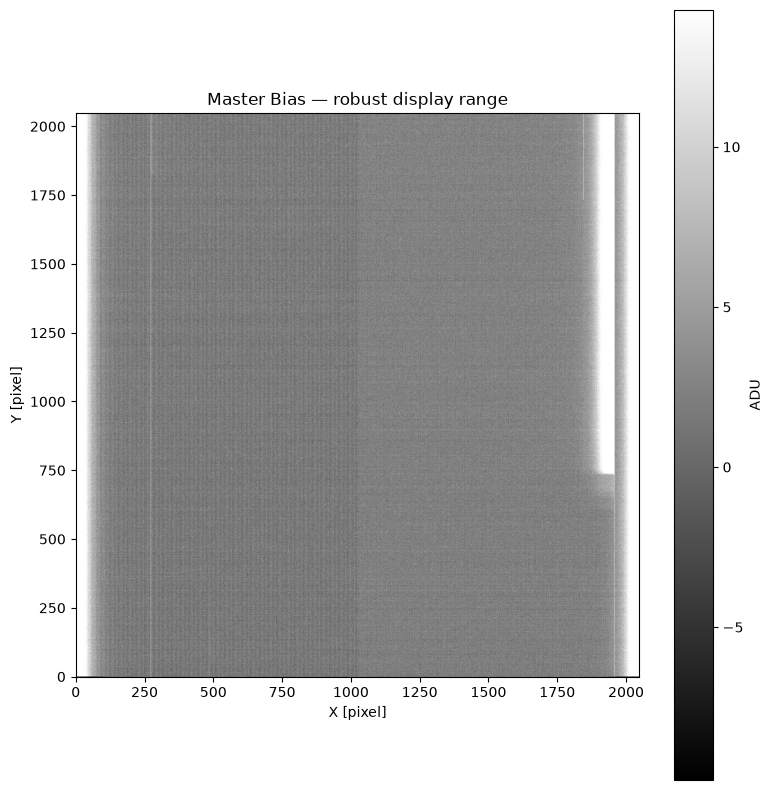

In [7]:
vmin = median_clip - 5 * std_clip
vmax = median_clip + 5 * std_clip

plt.figure(figsize=(8, 8))
plt.imshow(master_bias, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Master Bias — robust display range")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "master_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## Save calibration product

In [9]:
master_header = fits.Header()
master_header["IMAGETYP"] = "MASTER_BIAS"
master_header["NCOMBINE"] = len(bias_files)
master_header["DETECTOR"] = "Tek2K_3"
master_header["CCDSUM"] = "1 1"
master_header["HISTORY"] = "Overscan corrected using BSEC11 and BSEC12"
master_header["HISTORY"] = "Trimmed using TSEC11 and TSEC12"
master_header["HISTORY"] = "Combined using median"

master_bias_path = PRODUCTS_DIR / "master_bias_new.fits"

fits.writeto(
    master_bias_path,
    master_bias.astype(np.float32),
    header=master_header,
    overwrite=True
)

print("Saved:", master_bias_path)

Saved: C:\Users\rodri\NoirLab\products\master_bias_new.fits
